In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from hmmlearn.hmm import GaussianHMM

from sklearn.preprocessing import StandardScaler

In [2]:

features = pd.read_csv(

    "../data/processed/features.csv",

    index_col=0,

    parse_dates=True

)

returns = pd.read_csv(

    "../data/processed/returns.csv",

    index_col=0,

    parse_dates=True

)

prices = pd.read_csv(

    "../data/processed/prices.csv",

    index_col=0,

    parse_dates=True

)

In [3]:

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [4]:
N_REGIMES = 4

model = GaussianHMM(

    n_components=N_REGIMES,

    covariance_type="full",

    n_iter=1000,

    random_state=42

)

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

scaled_features = pca.fit_transform(
    scaled_features
)

In [6]:
model.fit(scaled_features)

,n_components,4
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [7]:

hidden_states = model.predict(scaled_features)

regimes = pd.Series(

    hidden_states,

    index=features.index,

    name="Regime"

)


In [8]:
probabilities = model.predict_proba(

    scaled_features

)

probabilities_df = pd.DataFrame(

    probabilities,

    index=features.index

)

probabilities_df.columns = [

    f"Regime_{i}"

    for i in range(N_REGIMES)

]

In [10]:
aligned_returns = returns.loc[
    features.index
]


In [11]:
summary = []

for regime in np.unique(hidden_states):

    regime_mask = (

        regimes == regime

    )

    regime_returns = aligned_returns.loc[
        regime_mask,
        "^NSEI"
    ]

    annual_return = (
        regime_returns.mean() * 252
    )

    annual_vol = (
        regime_returns.std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return / annual_vol
    )

    summary.append({

        "Regime": regime,

        "Annual Return": annual_return,

        "Volatility": annual_vol,

        "Sharpe": sharpe

    })

summary_df = pd.DataFrame(summary)

print(summary_df)

   Regime  Annual Return  Volatility    Sharpe
0       0       0.091766    0.150122  0.611273
1       1       0.117081    0.444296  0.263520
2       2       0.343756    0.144327  2.381795
3       3       0.440362    0.138698  3.174981


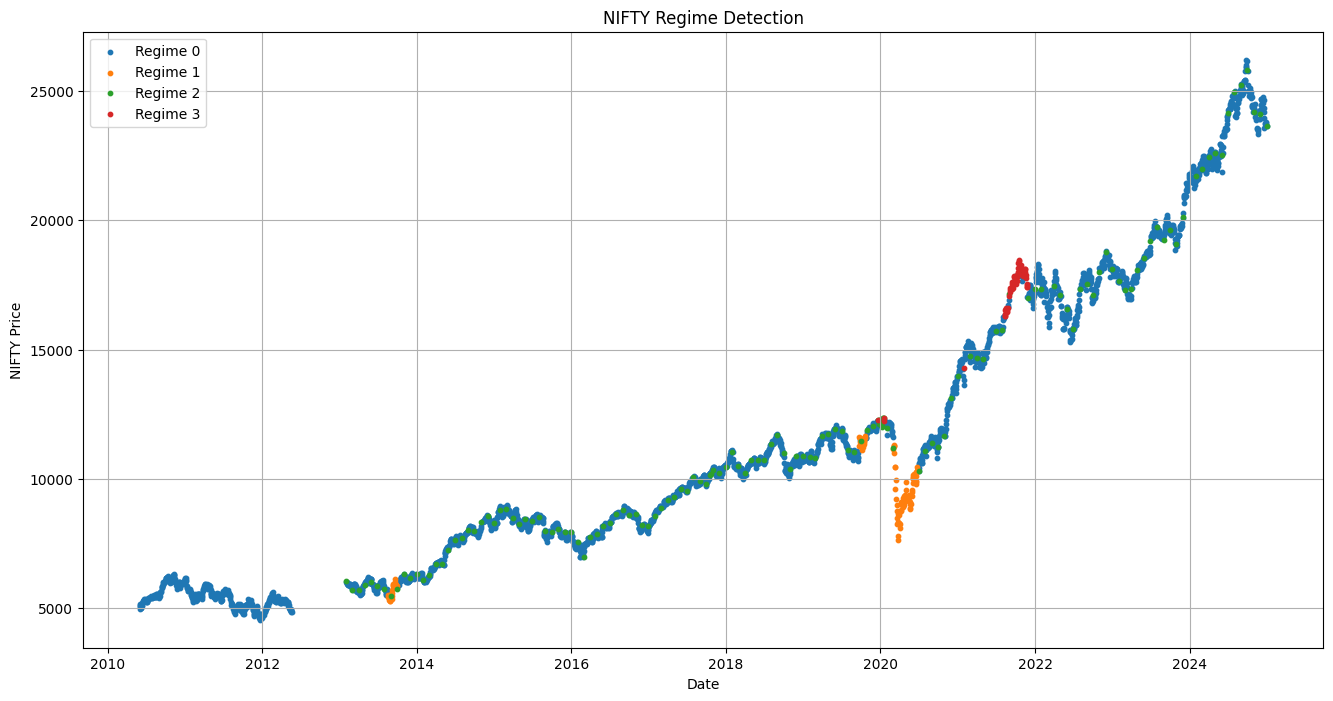

In [15]:
# ==========================================
# ALIGN PRICES
# ==========================================

aligned_prices = prices.loc[
    features.index
]

# ==========================================
# REGIME VISUALIZATION
# ==========================================

plt.figure(figsize=(16, 8))

for regime in np.unique(hidden_states):

    regime_mask = (
        regimes == regime
    )

    plt.scatter(

        aligned_prices.loc[
            regime_mask
        ].index,

        aligned_prices.loc[
            regime_mask,
            "^NSEI"
        ],

        label=f"Regime {regime}",

        s=10

    )

plt.legend()

plt.title(
    "NIFTY Regime Detection"
)

plt.xlabel("Date")

plt.ylabel("NIFTY Price")

plt.grid(True)

plt.savefig(
    "../reports/regime_detection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# ==========================================
# TRANSITION MATRIX
# ==========================================

transition_matrix = pd.DataFrame(

    model.transmat_,

    columns=[
        f"Regime_{i}"
        for i in range(N_REGIMES)
    ],

    index=[
        f"Regime_{i}"
        for i in range(N_REGIMES)
    ]

)

print()

print("=" * 50)

print("TRANSITION MATRIX")

print("=" * 50)

print(transition_matrix)

# ==========================================
# SAVE TRANSITION MATRIX
# ==========================================

transition_matrix.to_csv(

    "../data/processed/transition_matrix.csv"

)


TRANSITION MATRIX
          Regime_0  Regime_1  Regime_2  Regime_3
Regime_0  0.954099  0.000710  0.044534  0.000657
Regime_1  0.023710  0.958208  0.018082  0.000000
Regime_2  0.838701  0.019369  0.109677  0.032253
Regime_3  0.092600  0.000000  0.015452  0.891948


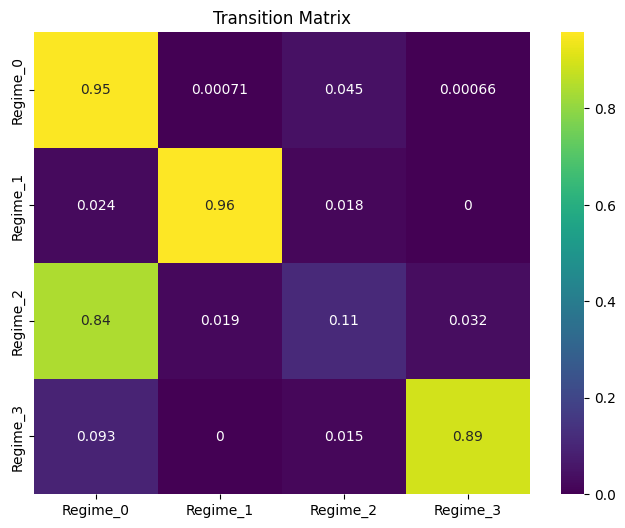

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(

    transition_matrix,

    annot=True,

    cmap="viridis"

)

plt.title("Transition Matrix")

plt.show()

In [19]:
regimes.to_csv(

    "../data/processed/regimes.csv"

)

transition_matrix.to_csv(

    "../data/processed/transition_matrix.csv"

)

summary_df.to_csv(

    "../data/processed/regime_summary.csv",

    index=False

)

probabilities_df.to_csv(

    "../data/processed/regime_probabilities.csv"

)
